In [1]:
# Label bias: does the collective opinion drift toward an answer option
# (+1/-1) irrespective of content, and how does that evolve over the 9
# rounds? Reproduces Figure S7 (Appendix C.2). Because the objective
# questions are label balanced (correct answer +1 as often as -1), a drift
# along this axis cannot be truth seeking; the subjective bank is not label
# balanced, so its curve mixes label and content effects.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import MODELS, REGIMES, load_data, opinions

runs, banks, P, GCLASS = load_data()
T = 9
CATS = ["pp", "nn", "np", "pn", "tie"]
CAT_LABEL = {"pp": "PP", "nn": "NN", "np": "NP", "pn": "PN", "tie": "U"}
CAT_COL = {"pp": "#9a9a9a", "nn": "#9a9a9a", "np": "#27ae60",
           "pn": "#e67e22", "tie": "#9a9a9a"}
CAT_DESC = {"np": "\u22121 \u2192 +1", "pn": "+1 \u2192 \u22121",
            "pp": "+1 \u2192 +1", "nn": "\u22121 \u2192 \u22121",
            "tie": "tie at an endpoint"}
REG_COL = {"objective": "black", "subjective": "#aeb2b8"}
REG_DESC = {"objective": "objective (balanced)",
            "subjective": "subjective (not balanced)"}

for r in runs:
    r["net"] = opinions(r).mean(axis=1)              # net opinion n(t)
print(len(runs), "societies (objective + subjective)")

9600 societies (objective + subjective)


In [2]:
# per model: % positive per round by regime (ties dropped) and the pooled
# endpoint (n(0), n(8)) with its transition category
pospct, endpoints, cats = {}, {}, {}
for model, label, short in MODELS:
    pospct[short] = {}
    for regime in REGIMES:
        net = np.array([r["net"] for r in runs
                        if r["model"] == model and r["mode"] == regime])
        pos, valid = net > 0, net != 0
        pospct[short][regime] = 100 * (pos & valid).sum(0) / valid.sum(0)
    net = np.array([r["net"] for r in runs if r["model"] == model])
    x, y = net[:, 0], net[:, -1]
    cat = np.where((x == 0) | (y == 0), "tie",
          np.where(x > 0, np.where(y > 0, "pp", "pn"),
                   np.where(y > 0, "np", "nn")))
    endpoints[short] = (x, y, cat)
    cats[short] = {c: int((cat == c).sum()) for c in CATS}
    o = pospct[short]["objective"]
    print(f"{label:13s} objective %+1 t=0 {o[0]:.1f}% -> t=8 {o[-1]:.1f}%, "
          f"NP {cats[short]['np']}, PN {cats[short]['pn']}")

GPT-4o-mini   objective %+1 t=0 47.7% -> t=8 52.9%, NP 373, PN 383
Gemma-3n-E4B  objective %+1 t=0 35.1% -> t=8 36.6%, NP 226, PN 168
Qwen3.5-9B    objective %+1 t=0 58.0% -> t=8 51.0%, NP 229, PN 607
Llama-3-8B    objective %+1 t=0 25.3% -> t=8 9.3%, NP 46, PN 469


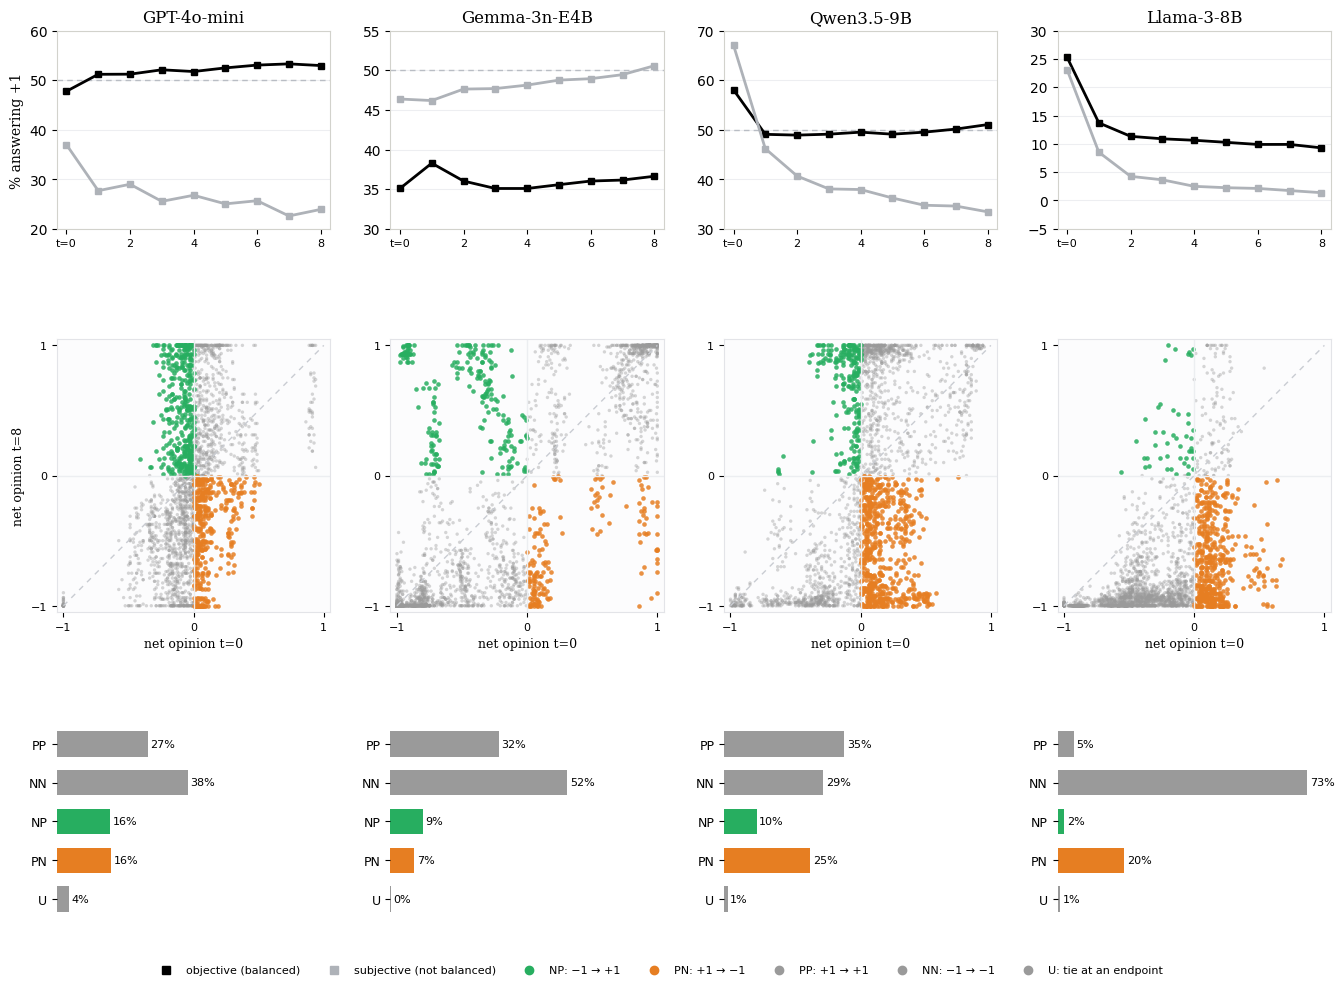

In [3]:
# per model: % positive lines, endpoint scatter (NP/PN highlighted), bars
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 4, height_ratios=[1.0, 1.7, 1.0], hspace=0.32,
                      wspace=0.22, left=0.07, right=0.98, top=0.94, bottom=0.05)
max_bar = max(100 * c / sum(cs.values()) for cs in cats.values()
              for c in cs.values())
for j, (model, label, short) in enumerate(MODELS):
    ax = fig.add_subplot(gs[0, j])
    ax.grid(axis="y", color="#edeef1", lw=0.8)
    ax.axhline(50, color="#b9bdc4", ls=(0, (4, 3)), lw=1)   # no-bias level
    for regime in REGIMES[::-1]:                             # objective on top
        ax.plot(range(T), pospct[short][regime], color=REG_COL[regime],
                lw=2, marker="s", ms=4)
    vals = np.concatenate([pospct[short][regime] for regime in REGIMES])
    lo = 5 * np.floor((vals.min() - 2) / 5)
    hi = 5 * np.ceil((vals.max() + 2) / 5)
    ax.set_ylim(lo, max(hi, lo + 10)), ax.set_xlim(-0.3, T - 0.7)
    ax.set_xticks(range(0, T, 2), ["t=0", "2", "4", "6", "8"], fontsize=8)
    ax.set_title(label, fontsize=12, family="serif")
    if j == 0:
        ax.set_ylabel("% answering +1", fontsize=10, family="serif")
    for s in ax.spines.values():
        s.set_color("#d2d2cc")

    ax = fig.add_subplot(gs[1, j])
    x, y, cat = endpoints[short]
    ax.set_facecolor("#fcfcfd")
    ax.axvline(0, color="#eceef1", lw=1), ax.axhline(0, color="#eceef1", lw=1)
    ax.plot([-1, 1], [-1, 1], color="#c9ccd2", ls=(0, (4, 4)), lw=1)
    bg = ~np.isin(cat, ["np", "pn"])
    ax.scatter(x[bg], y[bg], s=6, c=[CAT_COL[c] for c in cat[bg]],
               alpha=0.4, lw=0)
    for c in ["np", "pn"]:
        sel = cat == c
        ax.scatter(x[sel], y[sel], s=11, c=CAT_COL[c], alpha=0.85, lw=0)
    ax.set_xlim(-1.05, 1.05), ax.set_ylim(-1.05, 1.05)
    ax.set_xticks([-1, 0, 1]), ax.set_yticks([-1, 0, 1])
    ax.tick_params(labelsize=8)
    ax.set_xlabel("net opinion t=0", fontsize=9, family="serif")
    if j == 0:
        ax.set_ylabel("net opinion t=8", fontsize=9, family="serif")
    ax.set_aspect("equal")
    for s in ax.spines.values():
        s.set_color("#e3e4e8")

    ax = fig.add_subplot(gs[2, j])
    tot = sum(cats[short].values())
    pct = [100 * cats[short][c] / tot for c in CATS]
    ax.barh(range(len(CATS))[::-1], pct, color=[CAT_COL[c] for c in CATS],
            height=0.65)
    for i, p in enumerate(pct):
        ax.text(p + 0.8, len(CATS) - 1 - i, f"{p:.0f}%", va="center", fontsize=8)
    ax.set_yticks(range(len(CATS))[::-1], [CAT_LABEL[c] for c in CATS], fontsize=9)
    ax.set_xlim(0, 5 * np.ceil((max_bar + 4) / 5))
    ax.set_xticks([])
    for s in ax.spines.values():
        s.set_visible(False)
handles = [plt.Line2D([], [], marker="s", ls="", color=REG_COL[regime],
                      label=REG_DESC[regime]) for regime in REGIMES[::-1]]
handles += [plt.Line2D([], [], marker="o", ls="", color=CAT_COL[c],
                       label=f"{CAT_LABEL[c]}: {CAT_DESC[c]}")
            for c in ["np", "pn", "pp", "nn", "tie"]]
fig.legend(handles=handles, loc="lower center", ncol=7, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.015))
plt.show()

In [4]:
# Reconciling with the paper's text: C.2 quotes "the fraction answering +1
# falling from 39% to 16%" for Llama-3-8B. That number is the *vote share*
# (all K = 5 raw samples of all agents pooled), not the society-level share
# plotted in row 1 above (25% -> 9%). The vote share reproduces to within
# the usual data drift:
for model, label, short in MODELS:
    rows = [r for r in runs if r["model"] == model and r["mode"] == "objective"]
    raw = np.array([np.asarray(r["spins_raw_history"], float) for r in rows])
    pos = 100 * (raw > 0).sum(axis=(0, 2, 3)) / (raw != 0).sum(axis=(0, 2, 3))
    print(f"{label:13s} vote share of +1 (objective) "
          f"t=0 {pos[0]:.1f}% -> t=8 {pos[-1]:.1f}%")

GPT-4o-mini   vote share of +1 (objective) t=0 49.7% -> t=8 52.3%
Gemma-3n-E4B  vote share of +1 (objective) t=0 39.2% -> t=8 37.9%


Qwen3.5-9B    vote share of +1 (objective) t=0 50.1% -> t=8 51.3%
Llama-3-8B    vote share of +1 (objective) t=0 37.9% -> t=8 15.1%
